# Genomics Data Visualization · Day 2

**Genome-scale charts & comparative views** — the runnable companion to the
Day-2 deck. Each section gives you the *final, polished* version of a chart
the slides built step by step.

**How to use this notebook:**

1. Run the install cell once (it takes ~1 minute on Colab).
2. Run the setup cell to import everything.
3. Each chart cell is self-contained — you can rerun any of them in any order.

The Day-2 sections covered here:

- Stacked bar plots — admixture composition across populations
- Time series — gene expression trajectories with uncertainty
- Multiple sequence alignment (MSA) — colored conservation grid
- Manhattan plots — GWAS results genome-wide
- Genome stats — coverage QC, peak tracks, gene models
- pyCirclize — circular genome plots
- Synteny — comparing two genomes with ribbons

Every line has an inline comment. **Read the comments — they're the lesson.**


In [1]:
# One-line install: pulls the genomics_course package + all its dependencies
# (matplotlib, pandas, seaborn, plotly, pyCirclize, biopython, ...) directly
# from the course GitHub branch. Run this once per Colab session.
!pip install -q "git+https://github.com/loukesio/dataviz-genomicsdata.git@Python_2026"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 68.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.1/766.1 kB 38.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 81.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (p

In [2]:
# === Setup ===
# Single source of truth for palette, fonts, and rcParams. Importing the
# theme registers IBM Plex Mono, defines the Economist palette (GREEN, BLUE,
# AMBER, RED, PURPLE + neutrals INK/CREAM/LINE/MUTED/GREY), and applies the
# cream-canvas matplotlib rcParams so every later figure inherits the look.
from genomics_course.theme import *

# Loaders bundled with the package — no network calls needed.
from genomics_course.data import (
    load_gwas,        # GWAS height: chrom, pos, pval, snp
    load_admixture,   # individual, population, K1..K5
    load_qc,          # sample, raw, callable, loss
    load_peaks,       # position, H3K27ac, H3K4me3, ATAC
    load_peak_genes,  # name, start, end, strand
    load_timecourse,  # gene, time, tpm, sem
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches            # for synteny ribbons
import warnings
warnings.filterwarnings("ignore")

rng = np.random.default_rng(11)                  # day-2 seed
print("setup OK — palette:", [GREEN, BLUE, AMBER, RED, PURPLE])


setup OK — palette: ['#379A8B', '#006BA2', '#EBB434', '#B4405F', '#9A607F']


## 1 · Stacked Bar — Admixture

Each column is one individual; the column height (always 1.0) is split into
five K components. Sort within each population, then stack to reveal who is
"pure" and who is admixed.


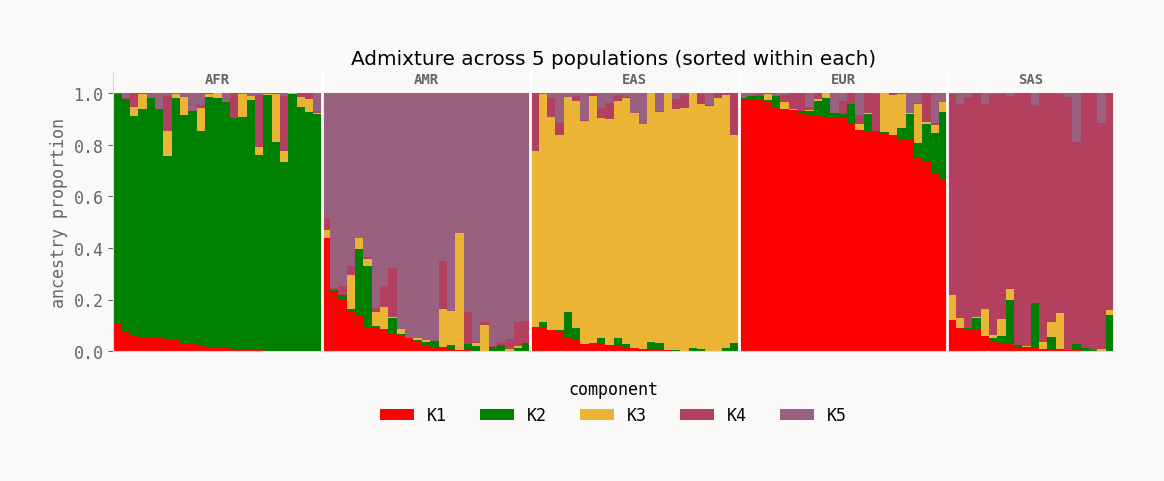

In [19]:
my_pal = ["red", "green", "#EBB434", "#B4405F", "#9A607F"]  # 5 colours, 5 K's


# === Stacked bar: admixture ===
adm = load_admixture().copy()                          # one row per individual
K_cols = ["K1", "K2", "K3", "K4", "K5"]                # the five components
pop_order = ["EUR", "EAS", "AFR", "AMR", "SAS"]        # left-to-right populations

# sort individuals within each population by their dominant component, then by K1
adm["dominant"] = adm[K_cols].idxmax(axis=1)           # which K is biggest
adm = (adm.sort_values(["population", "dominant", "K1"], ascending=[True, True, False])
          .reset_index(drop=True))
adm["x"] = np.arange(len(adm))                         # bar x-position

fig, ax = plt.subplots(figsize=(11, 4.2))              # CREATE: wide canvas
bottom = np.zeros(len(adm))                            # running cumulative height

for K, color in zip(K_cols, my_pal):               # one stack layer per K
    ax.bar(adm["x"], adm[K],                           # CALL: bars at every x
           bottom=bottom,                              # start where previous stack ended
           width=1.0, color=color, label=K,
           edgecolor="none")
    bottom += adm[K].to_numpy()                        # update for next layer

# population separators + labels
for pop in pop_order:
    sub = adm[adm["population"] == pop]
    if sub.empty:
        continue
    ax.axvline(sub["x"].max() + 0.5, color="white", lw=2)    # vertical separator
    ax.text(sub["x"].mean(), 1.04, pop, ha="center",       # population label
            color=MUTED, fontsize=10, fontweight="bold")

ax.set_xlim(-0.5, len(adm) - 0.5)                      # tight x-range
ax.set_ylim(0, 1.08)                                   # room for top labels
ax.set_ylabel("ancestry proportion")
ax.set_xticks([])                                      # no per-individual ticks
ax.set_title("Admixture across 5 populations (sorted within each)", fontfamily="Arial")
ax.legend(ncol=5, frameon=False, title="component",
          loc="upper center", bbox_to_anchor=(0.5, -0.05))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
mport matplotlib as mpl
mpl.rcParams["font.family"] = "IBM Plex Mono"   # every title, label, tick from now on
mpl.rcParams["font.size"]   = 11                # base size for everything
mpl.rcParams["axes.prop_cycle"] = cycler(color=["#006BA2", "#379A8B", "#EBB434", "#B4405F", "#9A607F"])


In [11]:
adm

,individual,population,K1,K2,K3,K4,K5,dominant,x
0,AFR_015,AFR,1.071090e-01,0.888237,4.639277e-05,0.003721,0.000886,K2,0
1,AFR_012,AFR,7.488122e-02,0.901561,2.762670e-04,0.005847,0.017434,K2,1
2,AFR_019,AFR,5.694290e-02,0.855364,3.483568e-02,0.052478,0.000380,K2,2
3,AFR_017,AFR,5.640945e-02,0.883846,5.826651e-02,0.001232,0.000246,K2,3
4,AFR_009,AFR,5.467517e-02,0.928098,4.247754e-05,0.000303,0.016881,K2,4
...,...,...,...,...,...,...,...,...,...
115,SAS_017,SAS,2.721965e-03,0.026469,2.160058e-06,0.781727,0.189079,K4,115
116,SAS_001,SAS,1.045873e-03,0.011755,2.996446e-10,0.986999,0.000200,K4,116
117,SAS_000,SAS,3.176134e-04,0.003674,6.026912e-05,0.995296,0.000652,K4,117
118,SAS_009,SAS,1.353457e-04,0.000073,8.218239e-03,0.877437,0.114136,K4,118


## 2 · Time Series — Gene Expression with Uncertainty

Six genes, five timepoints, mean ± SEM as a ribbon. Bracket access on
`g["sem"]` is mandatory — `g.sem` returns the DataFrame method, not the
column!


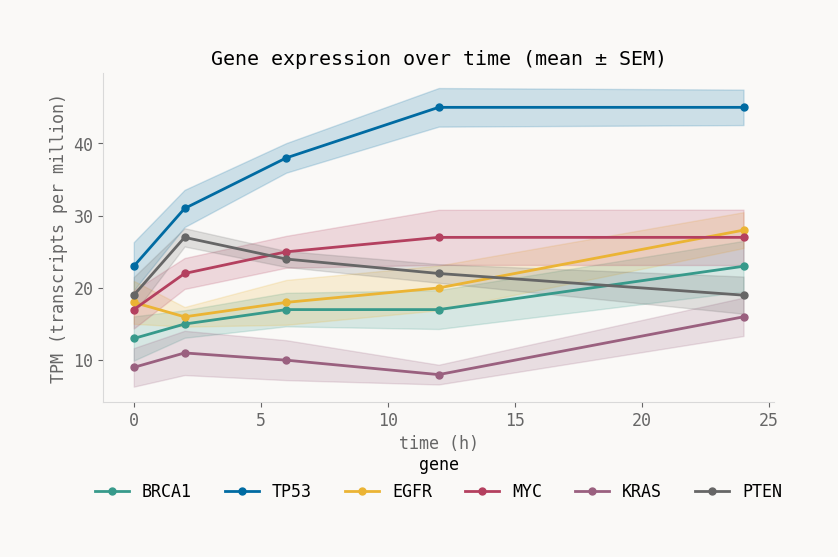

In [24]:
# === Time series: gene expression ± SEM ===
tc = load_timecourse()                                  # gene, time, tpm, sem
genes  = tc["gene"].unique()                            # 6 genes
colors = COURSE_PAL + ["#666666"]                       # 5 palette + 1 grey

fig, ax = plt.subplots(figsize=(8, 5))                  # CREATE

for each, gene in zip(colors, genes):
    g = tc[tc["gene"] == gene].sort_values("time")      # this gene's trajectory
    # central line + ribbon for ± SEM
    ax.plot(g["time"], g["tpm"], color=each, lw=2, marker="o",  # CALL
            markersize=5, label=gene, zorder=3)
    ax.fill_between(g["time"],                          # ribbon span
                    g["tpm"] - g["sem"],
                    g["tpm"] + g["sem"],
                    color=each, alpha=0.18, zorder=2)

ax.set_xlabel("time (h)")
ax.set_ylabel("TPM (transcripts per million)")
ax.set_title("Gene expression over time (mean ± SEM)")
ax.legend(frameon=False, title="gene",
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


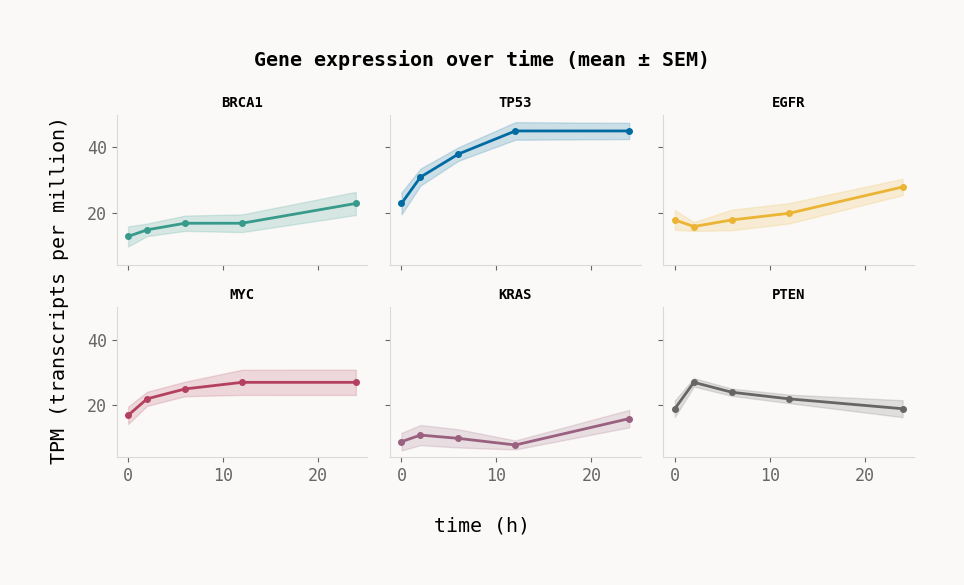

In [23]:
# === Small multiples: one gene per panel ===
tc = load_timecourse()                                  # gene, time, tpm, sem
genes  = tc["gene"].unique()                            # 6 genes
colors = COURSE_PAL + ["#666666"]                       # 5 palette + 1 grey

# CREATE a 2x3 GRID of axes (not one). sharex/sharey = every frame on the same scale
fig, axes = plt.subplots(2, 3, figsize=(9, 5), sharex=True, sharey=True)
axflat = axes.flatten()                                 # turn the 2x3 grid into a flat list of 6

for axi, color, gene in zip(axflat, colors, genes):     # pair each gene with ITS OWN axes
    g = tc[tc["gene"] == gene].sort_values("time")      # this gene's trajectory, time-ordered
    axi.plot(g["time"], g["tpm"], color=color, lw=2,    # draw onto axi, not the shared ax
             marker="o", markersize=4, zorder=3)
    axi.fill_between(g["time"],                          # ± SEM ribbon, same panel
                     g["tpm"] - g["sem"], g["tpm"] + g["sem"],
                     color=color, alpha=0.18, zorder=2)
    axi.set_title(gene, fontsize=10, fontweight="bold")  # the gene name labels its own panel
    axi.spines[["top", "right"]].set_visible(False)

fig.supxlabel("time (h)")                               # ONE shared x-label for the whole grid
fig.supylabel("TPM (transcripts per million)")          # ONE shared y-label
fig.suptitle("Gene expression over time (mean ± SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

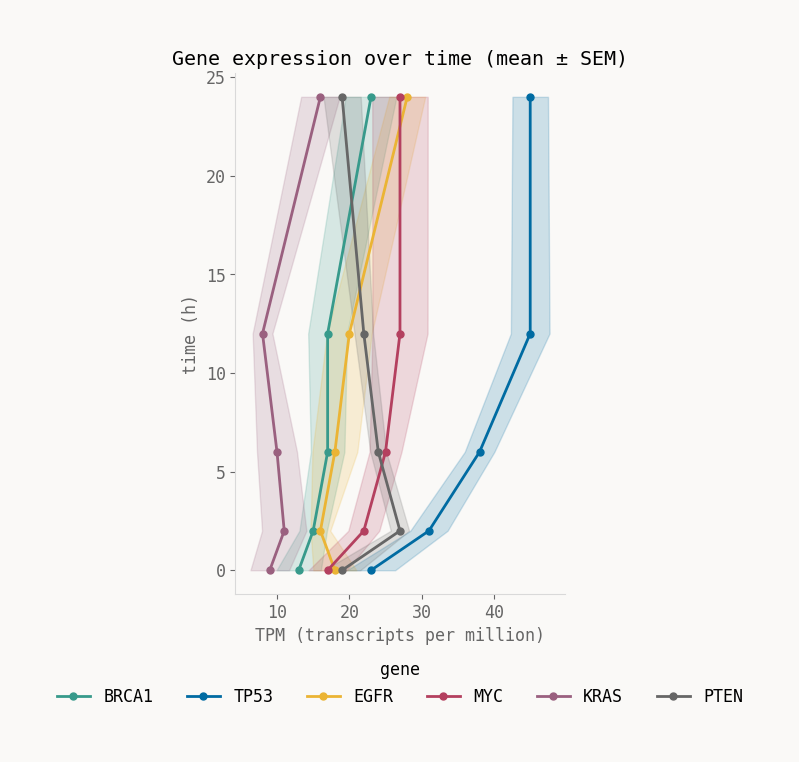

In [25]:
# === Time series: gene expression ± SEM (axes swapped) ===
tc = load_timecourse()                                  # gene, time, tpm, sem
genes  = tc["gene"].unique()                            # 6 genes
colors = COURSE_PAL + ["#666666"]                       # 5 palette + 1 grey

fig, ax = plt.subplots(figsize=(6, 7))                  # taller than wide now (time runs up)

for each, gene in zip(colors, genes):
    g = tc[tc["gene"] == gene].sort_values("time")      # still order by time
    # central line: TPM on x, time on y  ← arguments swapped
    ax.plot(g["tpm"], g["time"], color=each, lw=2, marker="o",
            markersize=5, label=gene, zorder=3)
    # ribbon now spans LEFT-RIGHT in x → use fill_betweenx
    ax.fill_betweenx(g["time"],                         # the shared axis is y (time)
                     g["tpm"] - g["sem"],               # left edge of the band
                     g["tpm"] + g["sem"],               # right edge of the band
                     color=each, alpha=0.18, zorder=2)

ax.set_xlabel("TPM (transcripts per million)")          # x label ↔ y label swapped too
ax.set_ylabel("time (h)")
ax.set_title("Gene expression over time (mean ± SEM)")
ax.legend(frameon=False, title="gene",
          loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
tc

,gene,time,tpm,sem
0,BRCA1,0,13.0,3.062475
1,BRCA1,2,15.0,1.901278
2,BRCA1,6,17.0,2.320425
3,BRCA1,12,17.0,2.690532
4,BRCA1,24,23.0,3.510216
5,TP53,0,23.0,3.334770
6,TP53,2,31.0,2.574226
7,TP53,6,38.0,2.046750
8,TP53,12,45.0,2.671911
9,TP53,24,45.0,2.457599


## 3 · MSA — Colored Conservation Grid

A small synthetic alignment (8 sequences × 60 columns) with one inserted
gap region. Letters are colored by identity, with a conservation track
above so the eye lands on interesting columns immediately.


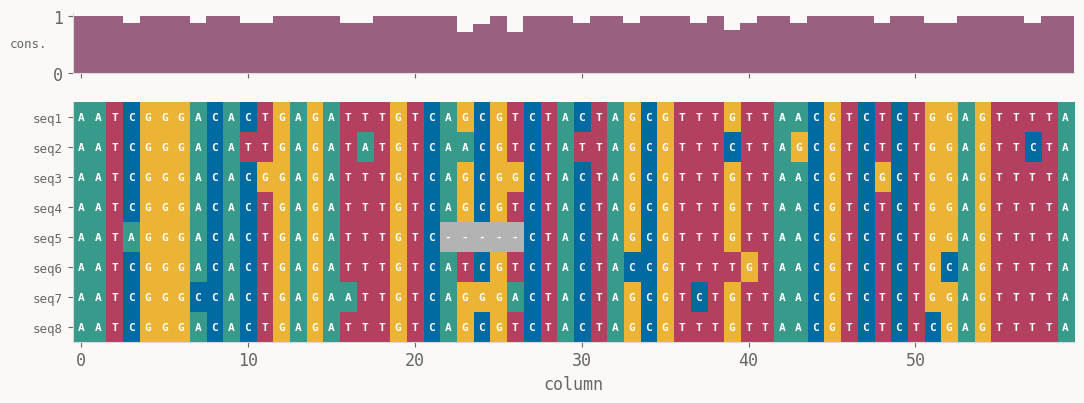

In [5]:
# === MSA: synthetic alignment + conservation track ===
ALPHABET = np.array(list("ACGT"))                       # bases we sample from
N_SEQ, N_COL = 8, 60                                    # alignment dimensions

# 1. build a base sequence + 7 mutants (5% mutation rate)
base = rng.choice(ALPHABET, N_COL)                      # ancestral sequence
aln  = np.tile(base, (N_SEQ, 1)).astype("<U1")          # start identical
for i in range(1, N_SEQ):                               # mutate all but row 0
    mask = rng.random(N_COL) < 0.05                     # 5% sites flip
    aln[i, mask] = rng.choice(ALPHABET, mask.sum())     # to a random base
aln[4, 22:27] = "-"                                     # insert a gap in row 4

# 2. colour map (DNA: identity-encoded; gap is grey)
PAL_BASE = {"A": GREEN, "C": BLUE, "G": AMBER, "T": RED, "-": GREY}
encode   = {b: i for i, b in enumerate("ACGT-")}
img = np.vectorize(encode.get)(aln).astype(float)       # numerical for imshow

from matplotlib.colors import ListedColormap
cmap = ListedColormap([PAL_BASE[b] for b in "ACGT-"])

# 3. conservation per column: fraction of most-common non-gap letter
def conservation(col):
    no_gap = col[col != "-"]
    if len(no_gap) == 0:
        return 0
    _, counts = np.unique(no_gap, return_counts=True)
    return counts.max() / len(no_gap)
cons = np.array([conservation(aln[:, c]) for c in range(N_COL)])

# 4. two-panel layout: conservation on top, alignment below
fig, (ax_top, ax) = plt.subplots(2, 1, figsize=(11, 4.2),
                                  gridspec_kw={"height_ratios": [1, 4]},
                                  sharex=True)
ax_top.bar(np.arange(N_COL), cons, color=PURPLE, width=1.0)   # conservation
ax_top.set_ylim(0, 1.05); ax_top.set_yticks([0, 1])
ax_top.set_ylabel("cons.", rotation=0, ha="right", va="center", fontsize=9, color=MUTED)
ax_top.spines[["top", "right"]].set_visible(False)

ax.imshow(img, aspect="auto", cmap=cmap, interpolation="nearest")  # heatmap
for r in range(N_SEQ):                                  # overlay letters in white
    for c in range(N_COL):
        ax.text(c, r, aln[r, c], ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")

ax.set_yticks(range(N_SEQ))
ax.set_yticklabels([f"seq{i+1}" for i in range(N_SEQ)], fontsize=9)
ax.set_xlabel("column")
plt.tight_layout()
plt.show()


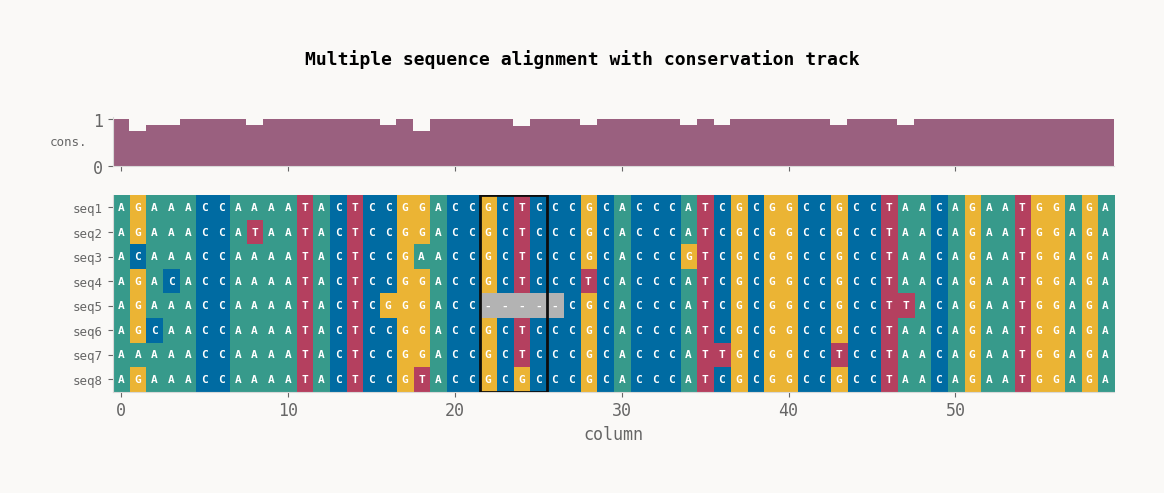

In [26]:
# === MSA: synthetic alignment + conservation track ===
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle                   # for the highlight box

ALPHABET = np.array(list("ACGT"))                          # bases we sample from
N_SEQ, N_COL = 8, 60                                       # alignment dimensions

# 1. build a base sequence + 7 mutants (5% mutation rate)
base = rng.choice(ALPHABET, N_COL)                         # ancestral sequence
aln  = np.tile(base, (N_SEQ, 1)).astype("<U1")             # start identical
for i in range(1, N_SEQ):                                  # mutate all but row 0
    mask = rng.random(N_COL) < 0.05                        # 5% sites flip
    aln[i, mask] = rng.choice(ALPHABET, mask.sum())        # to a random base
aln[4, 22:27] = "-"                                        # insert a gap in row 4

# 2. colour map (DNA: identity-encoded; gap is grey)
PAL_BASE = {"A": GREEN, "C": BLUE, "G": AMBER, "T": RED, "-": GREY}
encode   = {b: i for i, b in enumerate("ACGT-")}
img = np.vectorize(encode.get)(aln).astype(float)          # numerical for imshow
cmap = ListedColormap([PAL_BASE[b] for b in "ACGT-"])

# 3. conservation per column: fraction of most-common non-gap letter
def conservation(col):
    no_gap = col[col != "-"]
    if len(no_gap) == 0:
        return 0
    _, counts = np.unique(no_gap, return_counts=True)
    return counts.max() / len(no_gap)
cons = np.array([conservation(aln[:, c]) for c in range(N_COL)])

# 4. two-panel layout: conservation on top, alignment below
fig, (ax_top, ax) = plt.subplots(2, 1, figsize=(11, 4.2),
                                  gridspec_kw={"height_ratios": [1, 4]},
                                  sharex=True)
ax_top.bar(np.arange(N_COL), cons, color=PURPLE, width=1.0)    # conservation
ax_top.set_ylim(0, 1.05); ax_top.set_yticks([0, 1])
ax_top.set_ylabel("cons.", rotation=0, ha="right", va="center", fontsize=9, color=MUTED)
ax_top.spines[["top", "right"]].set_visible(False)

ax.imshow(img, aspect="auto", cmap=cmap, interpolation="nearest")  # heatmap
for r in range(N_SEQ):                                     # overlay letters in white
    for c in range(N_COL):
        ax.text(c, r, aln[r, c], ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")

ax.set_yticks(range(N_SEQ))
ax.set_yticklabels([f"seq{i+1}" for i in range(N_SEQ)], fontsize=9)
ax.set_xlabel("column")

# 5. HIGHLIGHT columns 22–25 with a hollow box (cells span ±0.5 around their integer)
ax.add_patch(Rectangle((21.5, -0.5), 4, N_SEQ,             # corner (x0, y0), width, height
                       fill=False, edgecolor=INK, lw=2, zorder=5))   # frame only, on top

# 6. TITLE over the whole figure
fig.suptitle("Multiple sequence alignment with conservation track",
             fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])                     # reserve top strip for the title
plt.show()

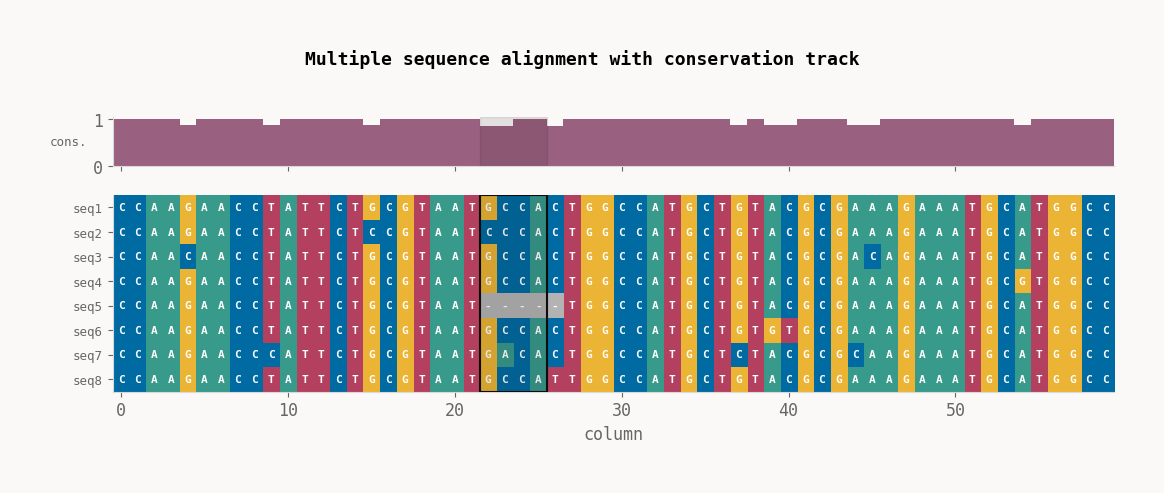

In [28]:
# === MSA: synthetic alignment + conservation track ===
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle                   # for the boxed outline

ALPHABET = np.array(list("ACGT"))                          # bases we sample from
N_SEQ, N_COL = 8, 60                                       # alignment dimensions

# 1. build a base sequence + 7 mutants (5% mutation rate)
base = rng.choice(ALPHABET, N_COL)                         # ancestral sequence
aln  = np.tile(base, (N_SEQ, 1)).astype("<U1")             # start identical
for i in range(1, N_SEQ):                                  # mutate all but row 0
    mask = rng.random(N_COL) < 0.05                        # 5% sites flip
    aln[i, mask] = rng.choice(ALPHABET, mask.sum())        # to a random base
aln[4, 22:27] = "-"                                        # insert a gap in row 4

# 2. colour map (DNA: identity-encoded; gap is grey)
PAL_BASE = {"A": GREEN, "C": BLUE, "G": AMBER, "T": RED, "-": GREY}
encode   = {b: i for i, b in enumerate("ACGT-")}
img = np.vectorize(encode.get)(aln).astype(float)          # numerical for imshow
cmap = ListedColormap([PAL_BASE[b] for b in "ACGT-"])

# 3. conservation per column: fraction of most-common non-gap letter
def conservation(col):
    no_gap = col[col != "-"]
    if len(no_gap) == 0:
        return 0
    _, counts = np.unique(no_gap, return_counts=True)
    return counts.max() / len(no_gap)
cons = np.array([conservation(aln[:, c]) for c in range(N_COL)])

# 4. two-panel layout: conservation on top, alignment below
fig, (ax_top, ax) = plt.subplots(2, 1, figsize=(11, 4.2),
                                  gridspec_kw={"height_ratios": [1, 4]},
                                  sharex=True)
ax_top.bar(np.arange(N_COL), cons, color=PURPLE, width=1.0)    # conservation
ax_top.set_ylim(0, 1.05); ax_top.set_yticks([0, 1])
ax_top.set_ylabel("cons.", rotation=0, ha="right", va="center", fontsize=9, color=MUTED)
ax_top.spines[["top", "right"]].set_visible(False)

ax.imshow(img, aspect="auto", cmap=cmap, interpolation="nearest")  # heatmap
for r in range(N_SEQ):                                     # overlay letters in white
    for c in range(N_COL):
        ax.text(c, r, aln[r, c], ha="center", va="center",
                color="white", fontsize=8, fontweight="bold")

ax.set_yticks(range(N_SEQ))
ax.set_yticklabels([f"seq{i+1}" for i in range(N_SEQ)], fontsize=9)
ax.set_xlabel("column")

# 5. HIGHLIGHT columns 22–25 as a tinted span on BOTH panels (shared x → they line up)
ax.axvspan(21.5, 25.5, color=INK, alpha=0.10, zorder=4)       # shade the alignment span
ax_top.axvspan(21.5, 25.5, color=INK, alpha=0.10)             # same span on the conservation bar
ax.add_patch(Rectangle((21.5, -0.5), 4, N_SEQ,                # crisp outline around the shaded cells
                        fill=False, edgecolor=INK, lw=1.5, zorder=5))

# 6. TITLE over the whole figure
fig.suptitle("Multiple sequence alignment with conservation track",
             fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])                     # reserve top strip for the title
plt.show()

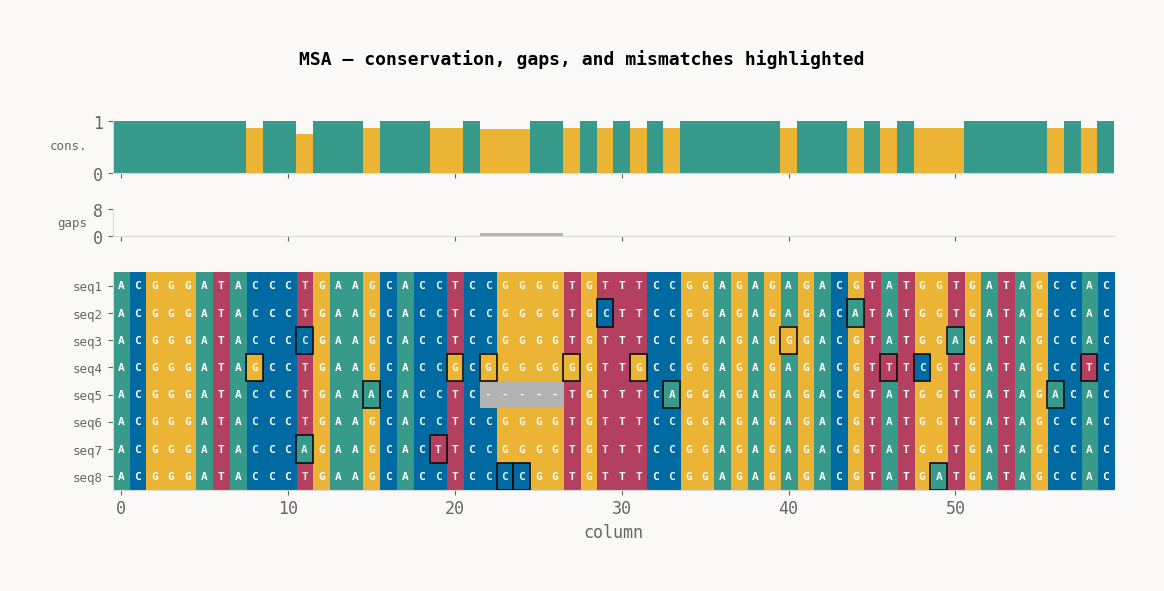

In [29]:
# === MSA: smart letters + mismatch rings + traffic-light conservation + gap track ===
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

ALPHABET = np.array(list("ACGT"))
N_SEQ, N_COL = 8, 60

# build ancestor + mutants
base = rng.choice(ALPHABET, N_COL)
aln  = np.tile(base, (N_SEQ, 1)).astype("<U1")
for i in range(1, N_SEQ):
    mask = rng.random(N_COL) < 0.08
    aln[i, mask] = rng.choice(ALPHABET, mask.sum())
aln[4, 22:27] = "-"

PAL_BASE = {"A": GREEN, "C": BLUE, "G": AMBER, "T": RED, "-": GREY}
encode   = {b: i for i, b in enumerate("ACGT-")}
img  = np.vectorize(encode.get)(aln).astype(float)
cmap = ListedColormap([PAL_BASE[b] for b in "ACGT-"])

# per-column conservation and gap count
def conservation(col):
    no_gap = col[col != "-"]
    if len(no_gap) == 0: return 0
    _, counts = np.unique(no_gap, return_counts=True)
    return counts.max() / len(no_gap)
cons = np.array([conservation(aln[:, c]) for c in range(N_COL)])
gaps = np.array([(aln[:, c] == "-").sum() for c in range(N_COL)])     # NEW: gaps per column

# THREE stacked tracks now: conservation, gaps, alignment
fig, (axc, axg, ax) = plt.subplots(3, 1, figsize=(11, 5.2), sharex=True,
                                   gridspec_kw={"height_ratios": [1, 0.5, 4]})

# traffic-light conservation bars: green ≥0.9, amber ≥0.7, else red
bar_cols = [GREEN if v >= 0.9 else (AMBER if v >= 0.7 else RED) for v in cons]
axc.bar(np.arange(N_COL), cons, color=bar_cols, width=1.0)
axc.set_ylim(0, 1.05); axc.set_yticks([0, 1])
axc.set_ylabel("cons.", rotation=0, ha="right", va="center", fontsize=9, color=MUTED)
axc.spines[["top", "right"]].set_visible(False)

# gap track
axg.bar(np.arange(N_COL), gaps, color=GREY, width=1.0)
axg.set_ylim(0, N_SEQ); axg.set_yticks([0, N_SEQ])
axg.set_ylabel("gaps", rotation=0, ha="right", va="center", fontsize=9, color=MUTED)
axg.spines[["top", "right"]].set_visible(False)

# alignment grid
ax.imshow(img, aspect="auto", cmap=cmap, interpolation="nearest")
for r in range(N_SEQ):
    for c in range(N_COL):
        differs = (aln[r, c] != aln[0, c]) and (aln[r, c] != "-")    # NEW: differs from ancestor?
        alpha   = 0.35 + 0.65 * cons[c]                              # NEW: fade variable columns
        ax.text(c, r, aln[r, c], ha="center", va="center",
                color="white", fontsize=8, fontweight="bold", alpha=alpha)
        if differs:                                                   # NEW: ring only mismatches
            ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1,
                                   fill=False, edgecolor=INK, lw=1.2, zorder=6))

ax.set_yticks(range(N_SEQ))
ax.set_yticklabels([f"seq{i+1}" for i in range(N_SEQ)], fontsize=9)
ax.set_xlabel("column")

fig.suptitle("MSA — conservation, gaps, and mismatches highlighted",
             fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 4 · Manhattan — GWAS Hits Genome-Wide

22 chromosomes laid end-to-end via cumulative position, alternating
colours so the eye separates them, two threshold lines, hits painted red
on top and labelled with their rsID.


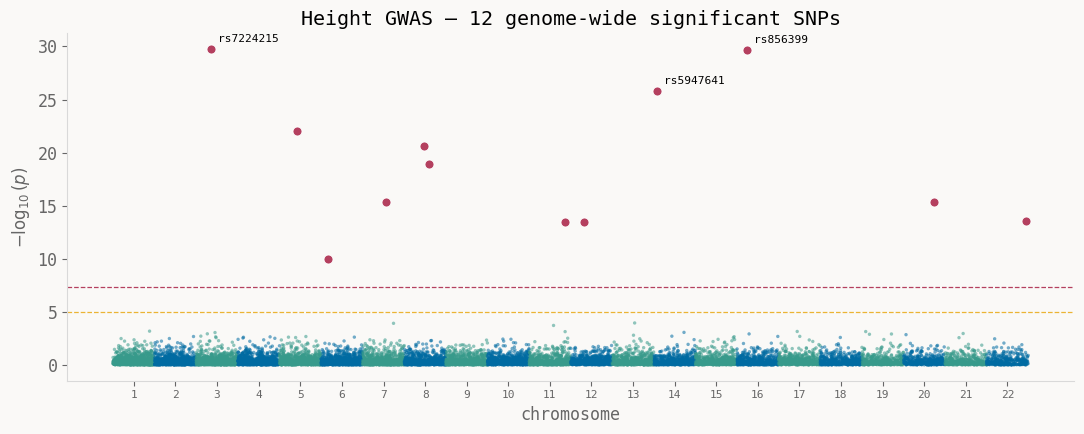

In [6]:
# === Manhattan plot: GWAS height ===
gwas = load_gwas("height").sort_values(["chrom", "pos"]).copy()
gwas["nlog10p"] = -np.log10(gwas["pval"])               # significance axis

# 1. cumulative x-position: chr2 starts where chr1 ended, ...
chrom_len = gwas.groupby("chrom")["pos"].max()
offsets   = chrom_len.cumsum().shift(fill_value=0)
gwas["cum_pos"] = gwas["pos"] + gwas["chrom"].map(offsets)

# 2. alternating colour per chromosome (parity)
palette = {True: BLUE, False: GREEN}
gwas["color"] = (gwas["chrom"] % 2 == 0).map(palette)

# 3. plot
fig, ax = plt.subplots(figsize=(11, 4.5))               # CREATE: wide canvas
ax.scatter(gwas["cum_pos"], gwas["nlog10p"],            # background cloud
           c=gwas["color"], s=6, alpha=0.55, linewidths=0)

# 4. threshold lines
ax.axhline(-np.log10(5e-8), color=RED,   lw=.9, ls="--")   # genome-wide
ax.axhline(-np.log10(1e-5), color=AMBER, lw=.9, ls="--")   # suggestive

# 5. spotlight the hits
hits = gwas[gwas["pval"] < 5e-8]
ax.scatter(hits["cum_pos"], hits["nlog10p"],
           color=RED, s=42, edgecolor="white", linewidths=0.6, zorder=5)
for _, row in hits.nsmallest(3, "pval").iterrows():     # label top 3
    ax.annotate(row["snp"], (row["cum_pos"], row["nlog10p"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)

# 6. tick at each chromosome midpoint
tick_pos = offsets + chrom_len / 2
ax.set_xticks(tick_pos); ax.set_xticklabels(chrom_len.index, fontsize=8)
ax.set_xlabel("chromosome")
ax.set_ylabel(r"$-\log_{10}(p)$")
ax.set_title(f"Height GWAS — {len(hits)} genome-wide significant SNPs")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


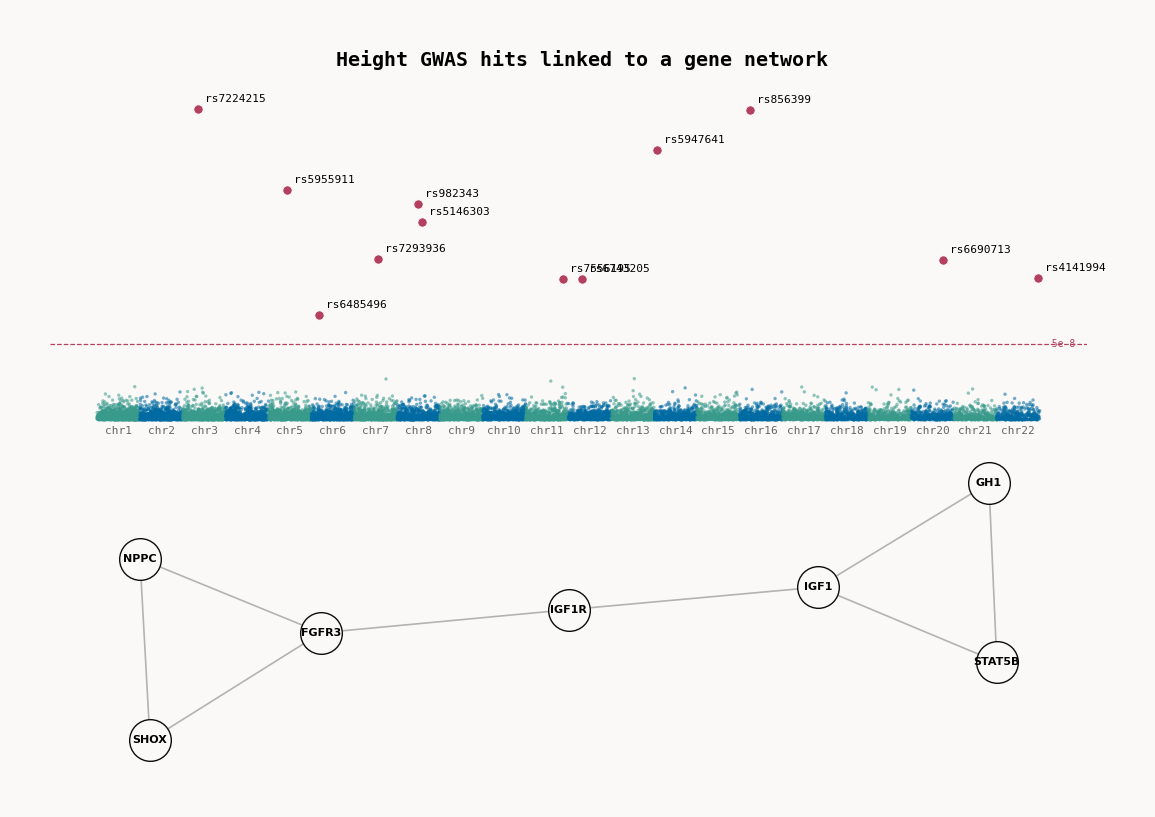

In [32]:
import networkx as nx
from matplotlib.patches import ConnectionPatch

# === build ALL derived columns in this one cell, so nothing can go missing ===
gwas = load_gwas("height").sort_values(["chrom", "pos"]).copy()
gwas["nlog10p"] = -np.log10(gwas["pval"])                      # significance axis
chrom_len = gwas.groupby("chrom")["pos"].max()
offsets   = chrom_len.cumsum().shift(fill_value=0)
gwas["cum_pos"] = gwas["pos"] + gwas["chrom"].map(offsets)     # genome-long x position
gwas["color"]   = (gwas["chrom"] % 2 == 0).map({True: BLUE, False: GREEN})
hits = gwas[gwas["pval"] < 5e-8]

# ---------- gene network ----------
G = nx.Graph()
G.add_edges_from([("GH1","IGF1"), ("IGF1","IGF1R"), ("IGF1R","FGFR3"),
                  ("FGFR3","SHOX"), ("SHOX","NPPC"), ("GH1","STAT5B"),
                  ("STAT5B","IGF1"), ("NPPC","FGFR3")])
posG = nx.spring_layout(G, seed=3)                             # reproducible node coords

hit_to_gene = {"rsHEIGHT1": "GH1", "rsHEIGHT2": "SHOX", "rsHEIGHT3": "IGF1R"}

# ---------- two stacked panels ----------
fig, (axm, axn) = plt.subplots(2, 1, figsize=(11, 7.5),
                               gridspec_kw={"height_ratios": [1.1, 1]})

# --- top: Manhattan, NO axis frame ---
axm.scatter(gwas["cum_pos"], gwas["nlog10p"], c=gwas["color"], s=6, alpha=.55, linewidths=0)
thr = -np.log10(5e-8)
axm.axhline(thr, color=RED, lw=.9, ls="--")                   # threshold line still draws fine
axm.text(gwas["cum_pos"].max(), thr, "  5e-8", color=RED, va="center", fontsize=7)
axm.scatter(hits["cum_pos"], hits["nlog10p"], color=RED, s=45,
            edgecolor="white", linewidths=.6, zorder=5)
for _, r in hits.iterrows():
    axm.annotate(r["snp"], (r["cum_pos"], r["nlog10p"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)
# chromosome names as plain TEXT (not ticks), since the axis is off
for c in chrom_len.index:
    axm.text(offsets[c] + chrom_len[c] / 2, -0.6, f"chr{c}",
             ha="center", va="top", fontsize=8, color=MUTED)
axm.set_axis_off()                                            # <-- no axis on the GWAS panel

# --- bottom: gene network, NO axis ---
nx.draw_networkx_edges(G, posG, ax=axn, edge_color=GREY, width=1.2)
nx.draw_networkx_nodes(G, posG, ax=axn, node_color=CREAM, edgecolors=INK, node_size=900)
nx.draw_networkx_labels(G, posG, ax=axn, font_size=8, font_weight="bold")
axn.set_axis_off()

# --- connectors: red string from each hit (top) to its gene (bottom) ---
for _, r in hits.iterrows():
    gene = hit_to_gene.get(r["snp"])
    if gene is None:
        continue
    con = ConnectionPatch(
        xyA=(r["cum_pos"], r["nlog10p"]), coordsA=axm.transData,   # SNP, top-panel coords
        xyB=posG[gene],                   coordsB=axn.transData,   # gene, bottom-panel coords
        color=RED, lw=1.2, alpha=.7, zorder=1)
    fig.add_artist(con)                                            # add to the FIGURE, not an axes
    nx.draw_networkx_nodes(G, posG, ax=axn, nodelist=[gene],
                           node_color=RED, edgecolors=INK, node_size=900, alpha=.85)
    nx.draw_networkx_labels(G, posG, ax=axn, labels={gene: gene},
                            font_size=8, font_weight="bold", font_color="white")

fig.suptitle("Height GWAS hits linked to a gene network", fontweight="bold")
plt.tight_layout()
plt.show()

## 5 · Genome Stats — Peak Tracks + Gene Model

Three ChIP/ATAC tracks share an x-axis with a gene model below. Same
contract as a paper figure: aligned axes tell a positional story.


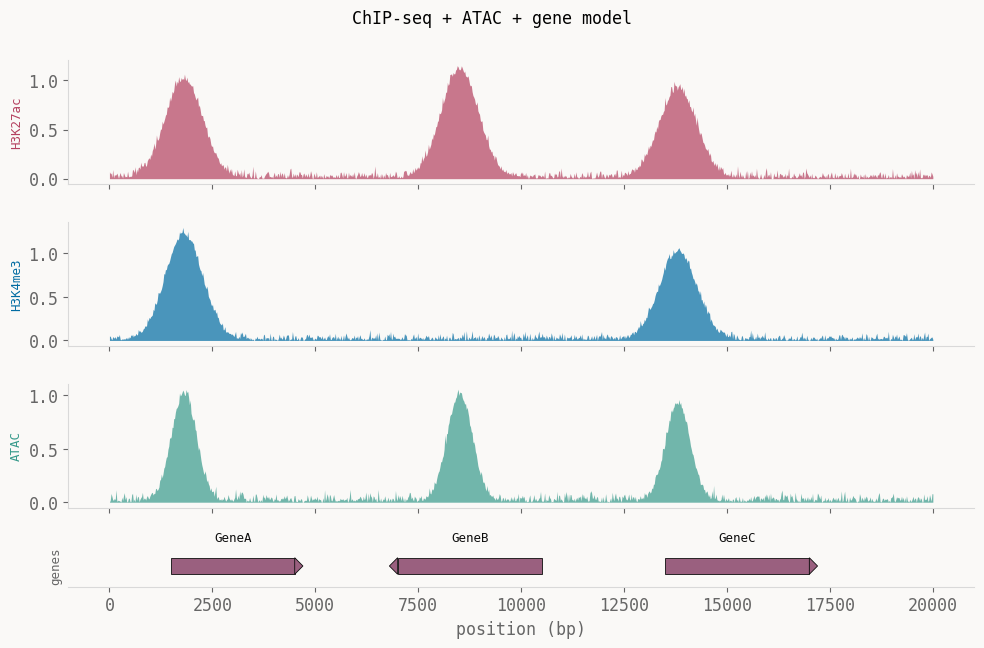

In [7]:
# === Genome stats: peak tracks + gene model ===
peaks = load_peaks()             # position, H3K27ac, H3K4me3, ATAC
genes = load_peak_genes()        # name, start, end, strand

# 4 vertical panels, shared x-axis (positional alignment is the contract)
fig, axes = plt.subplots(4, 1, figsize=(10, 6.5), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 3, 3, 1]))
ax_h3k27, ax_h3k4, ax_atac, ax_gene = axes

# track 1 — H3K27ac filled area, RED
ax_h3k27.fill_between(peaks["position"], peaks["H3K27ac"],
                      color=RED, alpha=0.7, linewidth=0)
ax_h3k27.set_ylabel("H3K27ac", color=RED, fontsize=9)

# track 2 — H3K4me3 filled area, BLUE
ax_h3k4.fill_between(peaks["position"], peaks["H3K4me3"],
                     color=BLUE, alpha=0.7, linewidth=0)
ax_h3k4.set_ylabel("H3K4me3", color=BLUE, fontsize=9)

# track 3 — ATAC filled area, GREEN
ax_atac.fill_between(peaks["position"], peaks["ATAC"],
                     color=GREEN, alpha=0.7, linewidth=0)
ax_atac.set_ylabel("ATAC", color=GREEN, fontsize=9)

# track 4 — gene model: a rectangle per gene + strand arrowhead
ax_gene.set_ylim(-0.5, 0.5)
ax_gene.set_yticks([])
for _, g in genes.iterrows():
    body = mpatches.Rectangle((g["start"], -0.2), g["end"] - g["start"], 0.4,
                              facecolor=PURPLE, edgecolor=INK, linewidth=0.6)
    ax_gene.add_patch(body)
    # arrowhead in strand direction
    if g["strand"] == "+":
        head = [(g["end"], -0.2), (g["end"] + 200, 0), (g["end"], 0.2)]
    else:
        head = [(g["start"], -0.2), (g["start"] - 200, 0), (g["start"], 0.2)]
    ax_gene.add_patch(mpatches.Polygon(head, facecolor=PURPLE,
                                        edgecolor=INK, linewidth=0.6))
    ax_gene.text((g["start"] + g["end"]) / 2, 0.6, g["name"],
                 ha="center", fontsize=9, color=INK)

ax_gene.set_xlabel("position (bp)")
ax_gene.set_ylabel("genes", color=MUTED, fontsize=9)

for ax in axes[:-1]:
    ax.spines[["top", "right"]].set_visible(False)
ax_gene.spines[["top", "right", "left"]].set_visible(False)

plt.suptitle("ChIP-seq + ATAC + gene model", y=0.995, fontsize=12)
plt.tight_layout()
plt.show()


## 6 · pyCirclize — Manhattan on a Ring with Chord Links

Same GWAS data, bent into a circle. SNP density on the outer track, hits
in red, and chords connecting the top hits across chromosomes.


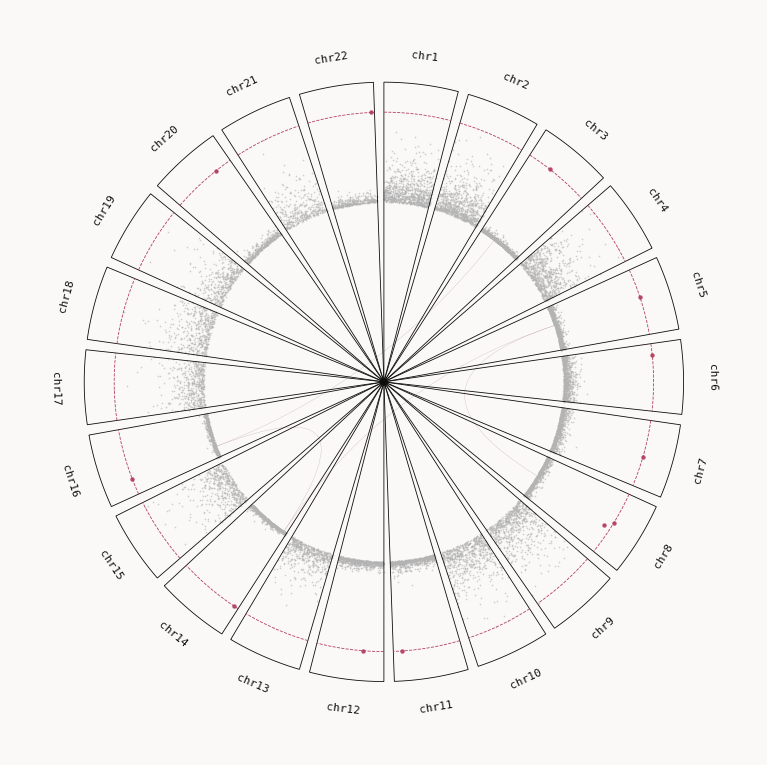

In [8]:
# === Circular plot: pyCirclize ===
from pycirclize import Circos                          # circular genome library

gwas = load_gwas("height").copy()                      # same table as Manhattan
gwas["nlog10p"] = -np.log10(gwas["pval"])
chrom_len = gwas.groupby("chrom")["pos"].max().to_dict()
sectors = {f"chr{c}": chrom_len[c] for c in sorted(chrom_len)}
gw_thresh = -np.log10(5e-8)

# CREATE the ring with 2deg gaps between sectors
circos = Circos(sectors, space=2)

for sector in circos.sectors:                          # iterate as list
    name = sector.name
    sector.text(name, r=108, size=8, color=INK)        # chromosome label (outside)
    sector.axis(fc=CREAM, ec=INK, lw=0.6)              # outer rim line

    # data track between radii 60-90 — the SNP cloud
    track = sector.add_track((60, 90))
    chrom_num = int(name.replace("chr", ""))
    df = gwas[gwas["chrom"] == chrom_num]
    track.scatter(df["pos"].to_numpy(), df["nlog10p"].to_numpy(),
                  s=1.5, color=GREY, alpha=0.6)        # background cloud

    # red hits — only draw if non-empty (most chroms have none)
    hits = df[df["pval"] < 5e-8]
    if not hits.empty:
        track.scatter(hits["pos"].to_numpy(), hits["nlog10p"].to_numpy(),
                      s=10, color=RED, alpha=0.95)

    # threshold ring at -log10(5e-8)
    track.line([0, chrom_len[chrom_num]], [gw_thresh, gw_thresh],
               color=RED, lw=0.6, ls="--")

# chord links between consecutive top-5 hits (different chromosomes)
top5 = gwas.nsmallest(5, "pval").reset_index(drop=True)
for i in range(len(top5) - 1):
    a, b = top5.iloc[i], top5.iloc[i + 1]
    if a["chrom"] == b["chrom"]:
        continue                                       # skip intra-chrom
    circos.link((f"chr{a['chrom']}", int(a['pos']) - 1, int(a['pos']) + 1),
                (f"chr{b['chrom']}", int(b['pos']) - 1, int(b['pos']) + 1),
                color=PURPLE, alpha=0.55)

fig = circos.plotfig(figsize=(7, 7))                   # CALL: returns matplotlib Figure
plt.show()


## 7 · Synteny — Ribbons Between Two Genomes

Two chromosomes drawn as horizontal tracks. Coloured polygons connect
homologous regions: grey = conserved (SYN), amber = inversion (INV),
blue = translocation (TRANS).


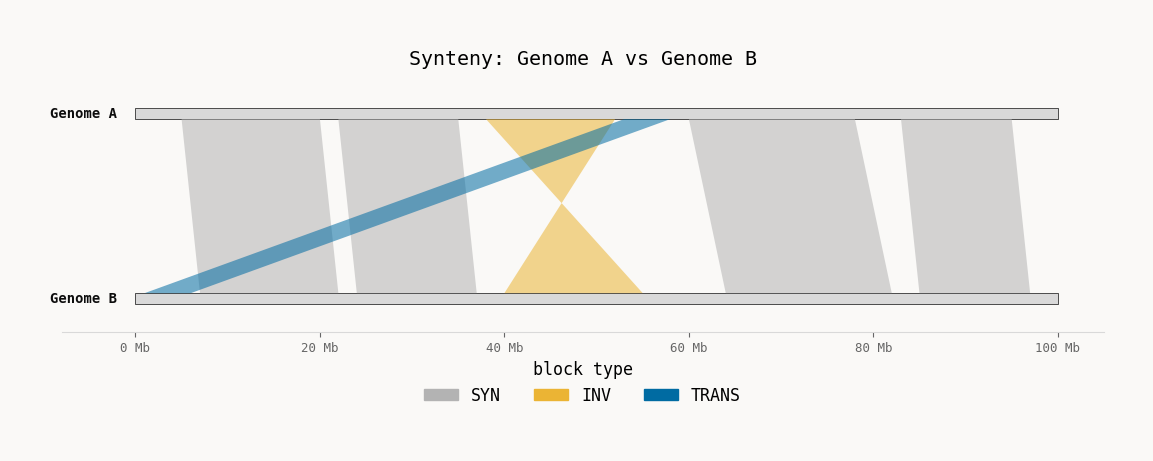

In [9]:
# === Synteny ribbons between two genomes ===
# Synthetic comparison: chr_A and chr_B, each 100 Mb. Hand-crafted blocks
# show every type a real comparison surfaces.
blocks = pd.DataFrame([
    # SYN — same order, same strand
    dict(chrA_start= 5, chrA_end=20, chrB_start= 7, chrB_end=22, type="SYN"),
    dict(chrA_start=22, chrA_end=35, chrB_start=24, chrB_end=37, type="SYN"),
    dict(chrA_start=60, chrA_end=78, chrB_start=64, chrB_end=82, type="SYN"),
    dict(chrA_start=83, chrA_end=95, chrB_start=85, chrB_end=97, type="SYN"),
    # INV — same range, flipped strand (chrB_start > chrB_end)
    dict(chrA_start=38, chrA_end=52, chrB_start=55, chrB_end=40, type="INV"),
    # TRANS — block at different positions in chrA vs chrB
    dict(chrA_start=53, chrA_end=58, chrB_start= 1, chrB_end= 6, type="TRANS"),
])

COLOUR = {"SYN": GREY, "INV": AMBER, "TRANS": BLUE}
TOP_Y, BOT_Y, H = 1.0, 0.0, 0.06                       # chromosome lane y/heights

fig, ax = plt.subplots(figsize=(11, 4))                # CREATE

# 1. chromosome lanes — two grey rectangles
for y, name in [(TOP_Y, "Genome A"), (BOT_Y, "Genome B")]:
    ax.add_patch(mpatches.Rectangle((0, y), 100, H,    # 100 Mb wide bar
                                     facecolor=LINE, edgecolor=INK, lw=0.5))
    ax.text(-2, y + H/2, name, ha="right", va="center",
            fontsize=10, fontweight="bold", color=INK)

# 2. synteny ribbons — one Polygon per block
for _, row in blocks.iterrows():
    # vertex order (clockwise): top-left, top-right, bottom-right, bottom-left
    verts = [
        (row["chrA_start"], TOP_Y),                    # top-left
        (row["chrA_end"],   TOP_Y),                    # top-right
        (row["chrB_end"],   BOT_Y + H),                # bottom-right (note: H lifts ribbon to top of lower lane)
        (row["chrB_start"], BOT_Y + H),                # bottom-left
    ]
    ax.add_patch(mpatches.Polygon(verts, closed=True,
                                   facecolor=COLOUR[row["type"]],
                                   edgecolor="none", alpha=0.55))

# 3. legend + frame polish
ax.legend(handles=[mpatches.Patch(color=COLOUR[t], label=t) for t in COLOUR],
          loc="upper center", bbox_to_anchor=(0.5, -0.05),
          frameon=False, ncol=3, title="block type")
ax.set_xlim(-8, 105); ax.set_ylim(-0.15, 1.25)
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x} Mb" for x in range(0, 101, 20)], fontsize=9)
ax.set_yticks([])
ax.set_title("Synteny: Genome A vs Genome B")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()


## Done

That's the full set of Day-2 plots. Every chart pulls from the bundled
`genomics_course` datasets, every line is annotated, every figure follows
the Economist palette + IBM Plex Mono via `from genomics_course.theme import *`.

Read the slide deck (`day2.html`) for the step-by-step builds; this notebook
is the polished destination they walk you to.
